In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel('default of credit card clients.xls', header=1)

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
x = df.drop(axis=1, columns=['ID', 'default payment next month'])
y = df['default payment next month'].values

In [6]:
df = df[~df.duplicated()]

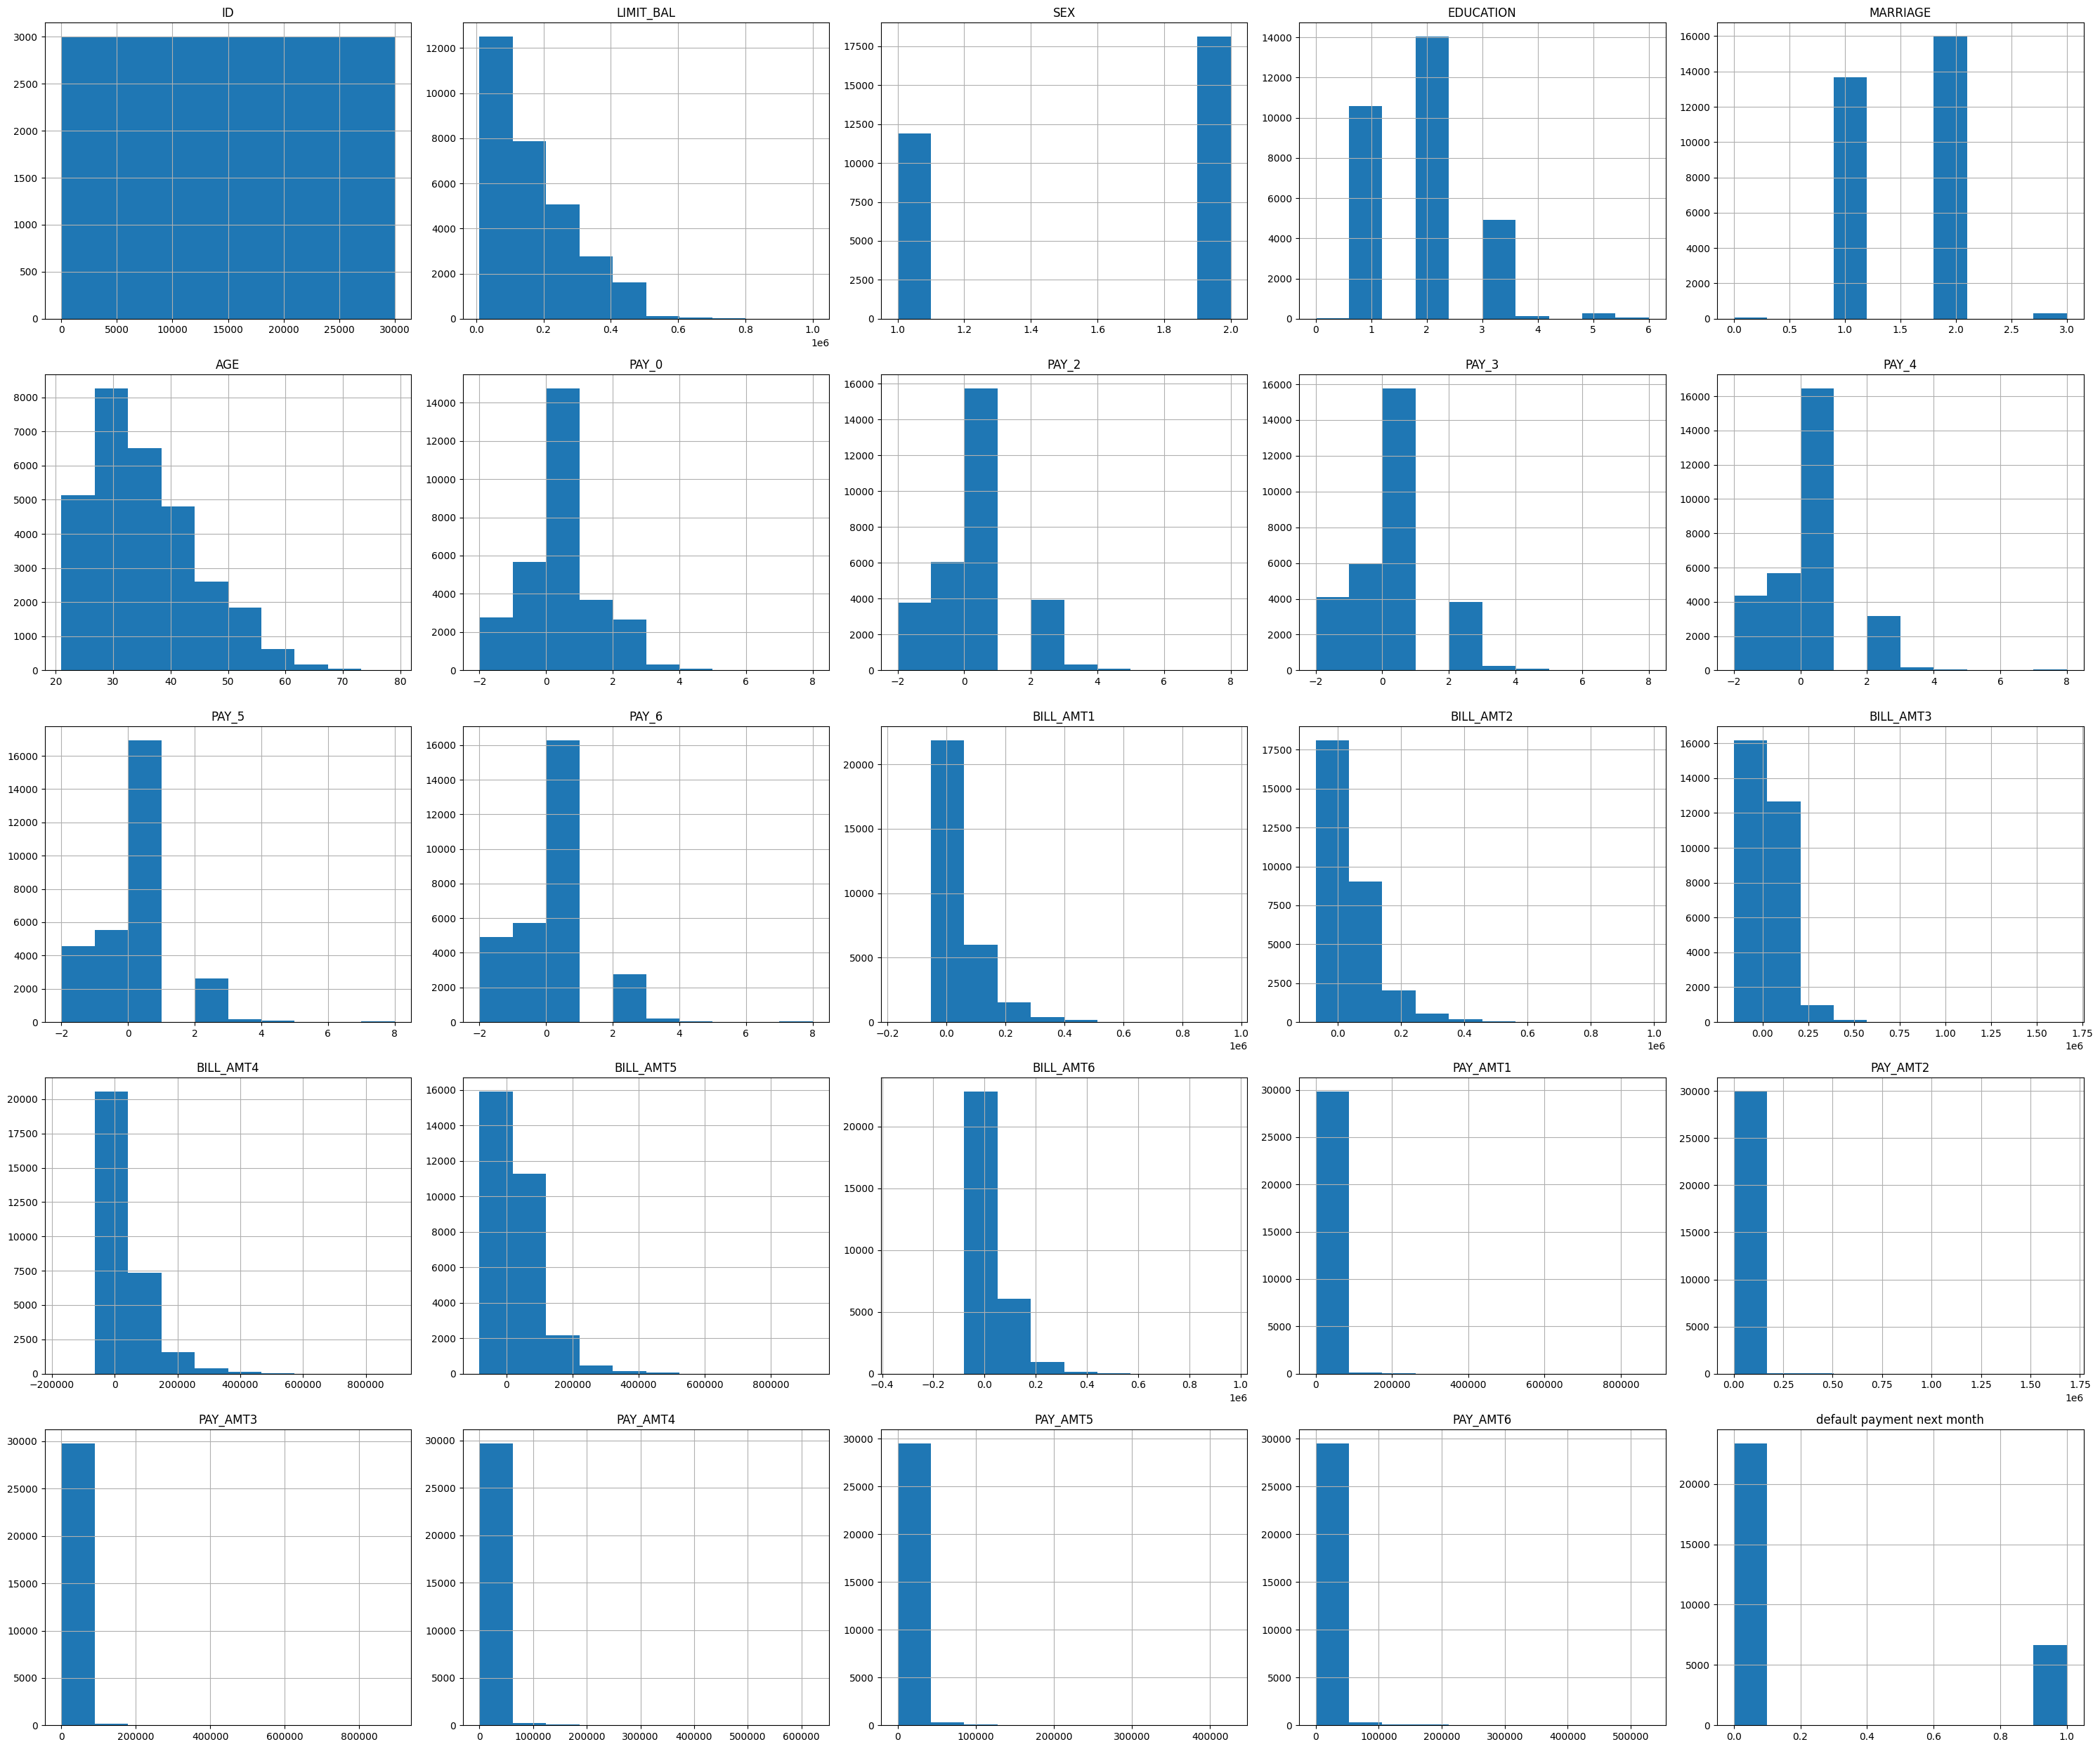

In [7]:
num_df = df.select_dtypes(include='number')
num_df.hist(
    bins=10,
    figsize=(30, 25)
)
plt.tight_layout()
plt.show()

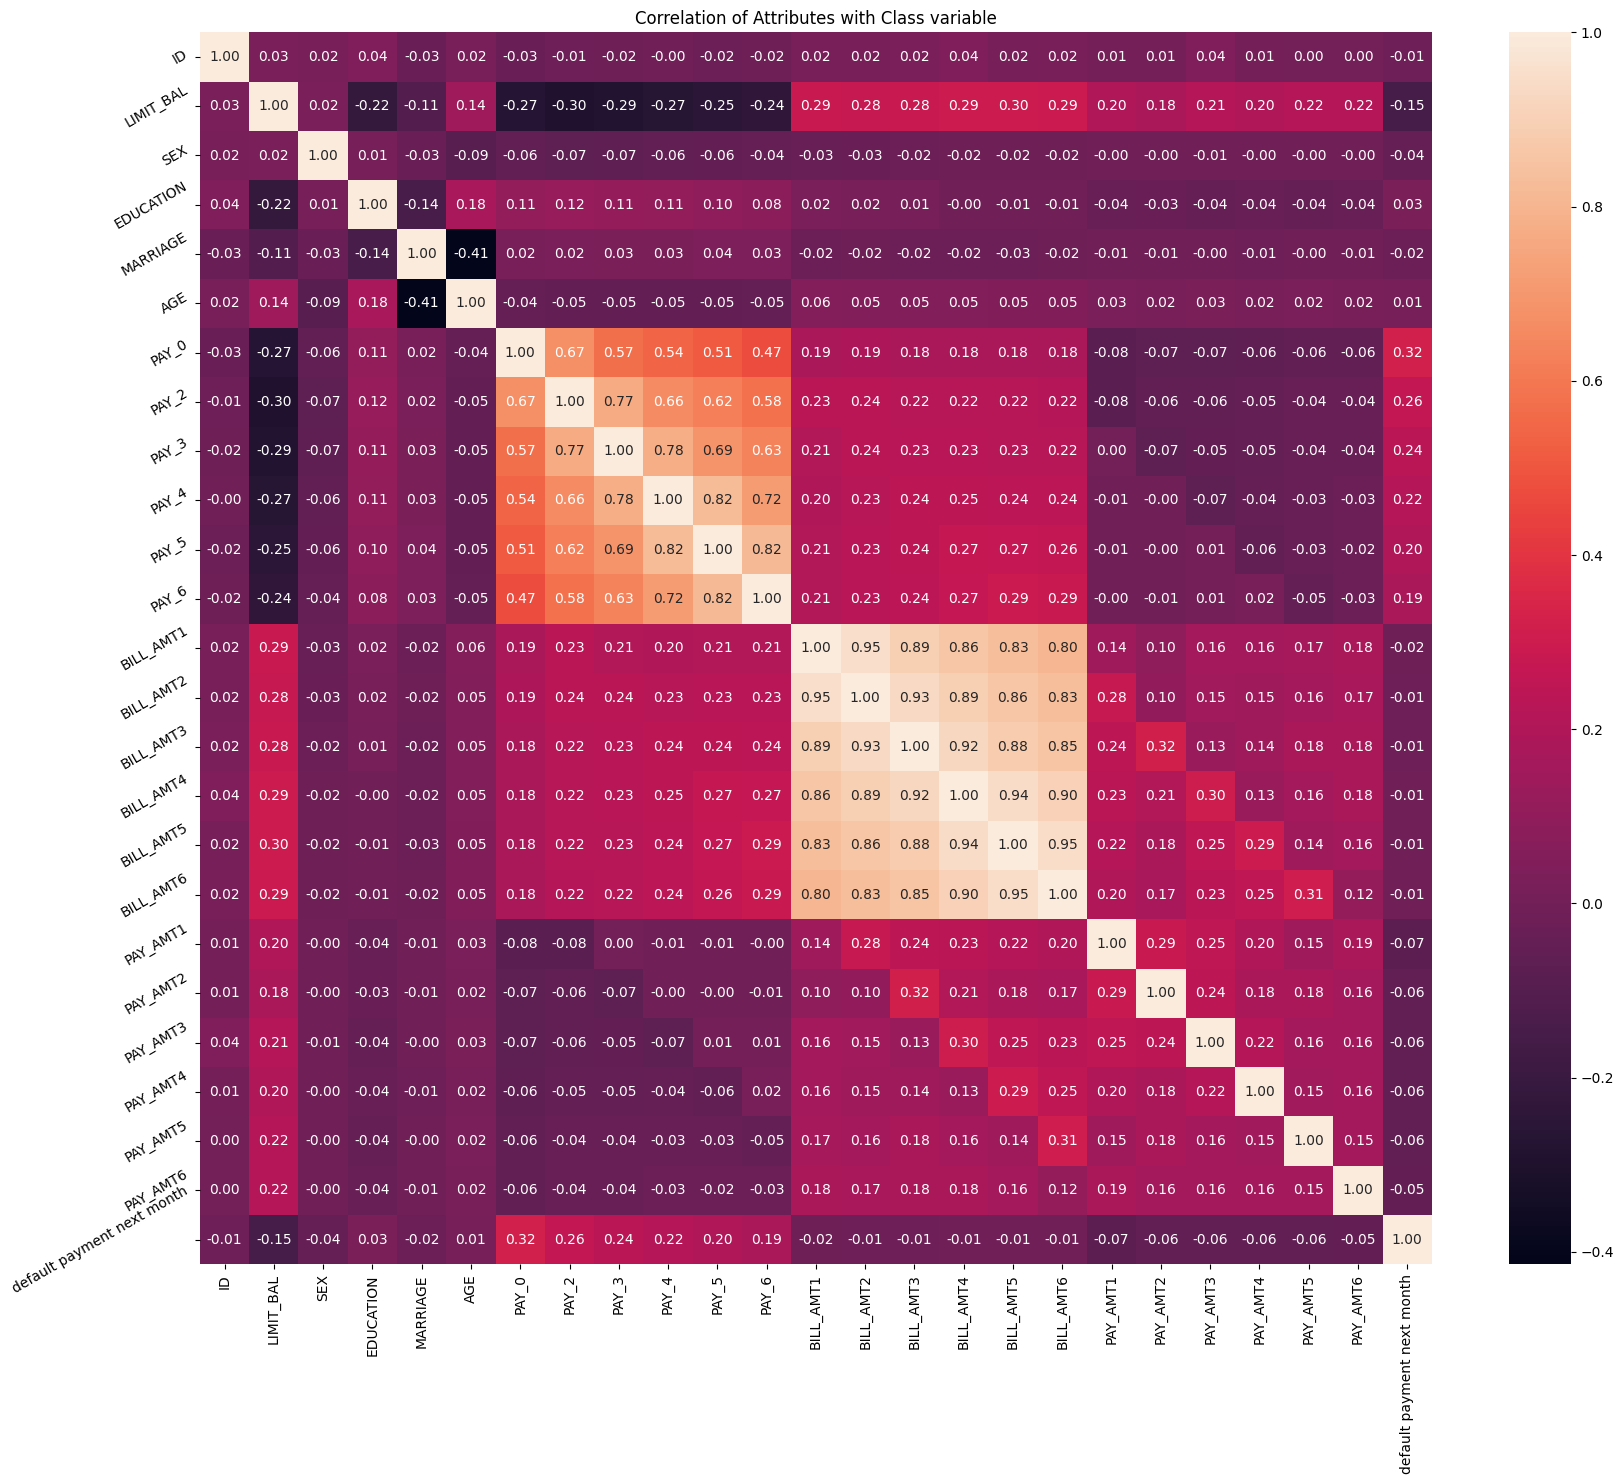

In [9]:
plt.figure(figsize=(20,16))
plt.title('Correlation of Attributes with Class variable')
a = sns.heatmap(correlation, square=True, annot=True, fmt='.2f', linecolor='white')
a.set_xticklabels(a.get_xticklabels(), rotation=90)
a.set_yticklabels(a.get_yticklabels(), rotation=30)
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
def knn_prediction(X_train, y_train, X_test, k=3):
    predictions = []
    for x in X_test:
        distances = np.linalg.norm(X_train - x, axis=1)
        knn_indices = np.argpartition(distances, k)[:k]
        predictions.append(np.bincount(y_train[knn_indices]).argmax())
    return np.array(predictions)


In [14]:
def kfold_knn_best_k(X, y, k_values, n_folds=5):
    n = len(X)
    indices = np.random.permutation(n)
    folds = np.array_split(indices, n_folds)
    mean_accuracies = {}
    for k in k_values:
        fold_accuracies = []
        for i in range(n_folds):
            val_idx = folds[i]
            train_idx = np.hstack([folds[j] for j in range(n_folds) if j != i])
            X_train, X_val = X[train_idx], X[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            y_pred = knn_prediction(X_train, y_train, X_val, k)
            acc = np.mean(y_pred == y_val)
            fold_accuracies.append(acc)
        mean_accuracies[k] = np.mean(fold_accuracies)
    best_k = max(mean_accuracies, key=mean_accuracies.get)
    return best_k, mean_accuracies


In [15]:
k_values = [3, 5, 7]
best_k, scores = kfold_knn_best_k(X_train, y_train, k_values, n_folds=3)

In [16]:
print("Best k value: ",best_k)
print("CV accuracies: ",scores)

Best k value:  7
CV accuracies:  {3: np.float64(0.7764583333333334), 5: np.float64(0.791375), 7: np.float64(0.8002916666666667)}


In [17]:
y_pred = knn_prediction(X_train, y_train, X_test, k=best_k)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))


Accuracy: 0.8033333333333333
F1 Score: 0.7826301509991034


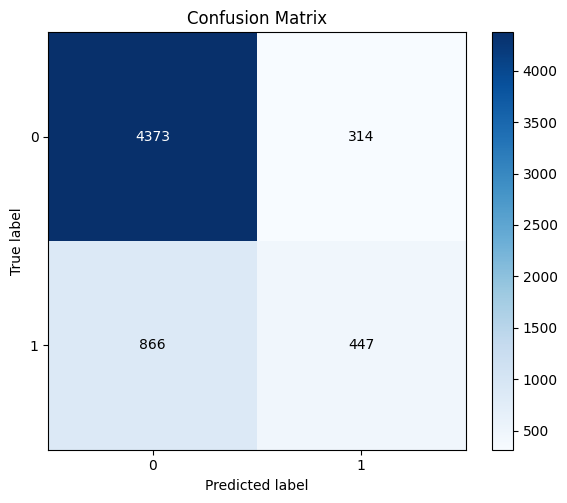

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(cm.shape[0])
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel("Predicted label")
plt.ylabel("True label")
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()


In [20]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Precision: 0.5873850197109067
Recall: 0.34044173648134046


In [21]:
def knn_predict_proba(X_train, y_train, X_test, k=best_k):
    scores = []
    for x in X_test:
        distances = np.linalg.norm(X_train - x, axis=1)
        knn_indices = np.argpartition(distances, k)[:k]
        positive_class_count = np.sum(y_train[knn_indices] == 1)
        scores.append(positive_class_count / k)
    return np.array(scores)

y_scores = knn_predict_proba(X_train, y_train, X_test, k=best_k)

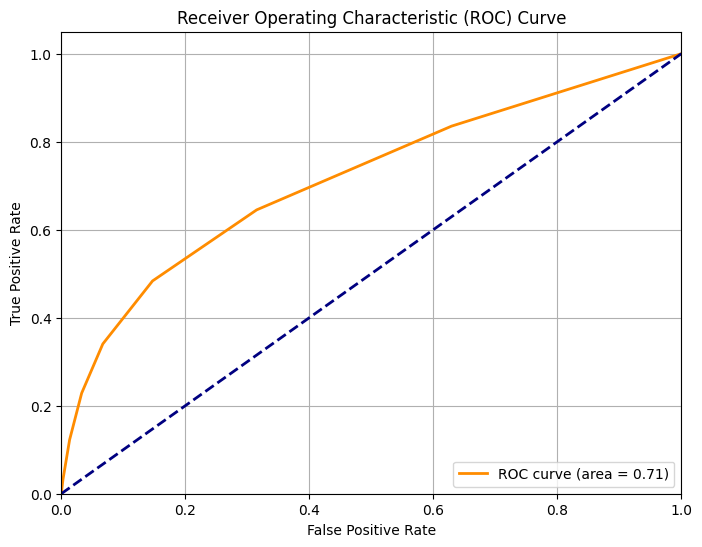

In [22]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()